# GLMM Brain-Behavior Analysis: Logistic Link (Binary Outcome)

**Purpose**: Replicate `11_lmm_brain_behavior.ipynb` but with a **logit link** for direction B (feature → decision), since `outcome` is binary. This allows comparison against the linear probability model (LPM) used in the LMM notebook.

**Method for binary outcome models**: `ConditionalLogit` (Chamberlain's fixed-effects logit), which conditions out all between-subject heterogeneity exactly — equivalent to a subject dummy-saturated logistic regression, but computationally efficient. Coefficients are log-odds, SE and p-values come from the conditional likelihood.

**Note on direction A** (behavior → feature): Features are continuous, so this direction stays as LMM (Gaussian) — same as notebook 11.

**Structure**: Same per-modality layout as notebook 11:
- Section 1 — EEG (16 features, 80 subjects)
- Section 2 — Pupil (13 features, 102 subjects)
- Section 3 — Gaze (16 features, 102 subjects)

In [1]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

import statsmodels.formula.api as smf
from statsmodels.discrete.conditional_models import ConditionalLogit

sns.set_style('whitegrid')
np.random.seed(42)
Path('../../data/results/main/statistical_analyses/logistic').mkdir(parents=True, exist_ok=True)

In [2]:
# ── Load data ──────────────────────────────────────────────────────────
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)
merged_df   = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
gaze_cols   = feature_data['gaze_cols']

with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)
eeg_df   = eeg_data['eeg_features_df'].copy()
eeg_cols = eeg_data['feature_columns']

print(f'Behavioral/physio: {len(merged_df)} trials, {merged_df["subject_id"].nunique()} subjects')
print(f'EEG:               {len(eeg_df)} trials, {eeg_df["subject_id"].nunique()} subjects')
print(f'EEG features ({len(eeg_cols)}): {eeg_cols}')
print(f'Pupil features ({len([c for c in physio_cols if c.endswith("_pre")])}): {[c for c in physio_cols if c.endswith("_pre")]}')
print(f'Gaze features ({len(gaze_cols)}): {gaze_cols}')

Behavioral/physio: 12107 trials, 102 subjects
EEG:               10212 trials, 80 subjects
EEG features (16): ['eeg_Delta_Frontal', 'eeg_Delta_Central', 'eeg_Delta_Parietal', 'eeg_Delta_Occipital', 'eeg_Theta_Frontal', 'eeg_Theta_Central', 'eeg_Theta_Parietal', 'eeg_Theta_Occipital', 'eeg_Alpha_Frontal', 'eeg_Alpha_Central', 'eeg_Alpha_Parietal', 'eeg_Alpha_Occipital', 'eeg_Beta_Frontal', 'eeg_Beta_Central', 'eeg_Beta_Parietal', 'eeg_Beta_Occipital']
Pupil features (13): ['pupil_mean_pre', 'pupil_std_pre', 'pupil_slope_pre', 'time_to_peak_pre', 'pupil_cv_pre', 'pupil_velocity_mean_pre', 'pupil_max_dilation_rate_pre', 'pupil_max_constriction_rate_pre', 'pupil_acceleration_std_pre', 'pct_time_dilating_pre', 'num_dilation_peaks_pre', 'eye_asymmetry_pre', 'eye_asymmetry_std_pre']
Gaze features (20): ['gaze_valid_pct', 'gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std', 'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std', 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_v

In [3]:
# ── Shared helpers & formulas ───────────────────────────────────────────
def zscore_cols(df, cols):
    df = df.copy()
    for c in cols:
        mu, sd = df[c].mean(), df[c].std()
        df[f'{c}_z'] = (df[c] - mu) / sd if sd > 0 else 0.0
    return df


def fit_clogit(outcome, predictors_df, groups):
    """
    Fit ConditionalLogit (fixed-effects logit). Drops subjects with no
    outcome variance (all 0 or all 1), since they contribute nothing to
    the conditional likelihood.
    Returns fitted result or None on failure.
    """
    df_fit = pd.DataFrame(predictors_df).copy()
    df_fit['_outcome'] = outcome.values
    df_fit['_group']   = groups.values

    # Drop subjects with no outcome variance
    var_mask = df_fit.groupby('_group')['_outcome'].transform('std') > 0
    df_fit = df_fit[var_mask].reset_index(drop=True)

    if len(df_fit) == 0 or df_fit['_group'].nunique() < 5:
        return None

    try:
        model  = ConditionalLogit(df_fit['_outcome'], df_fit.drop(columns=['_outcome','_group']),
                                  groups=df_fit['_group'])
        result = model.fit(disp=False)
        return result
    except Exception:
        return None


def scan_features(feature_cols, df, task_formula_cols, task_ctrl_cols, label='feature'):
    """
    Direction A: LMM  — ambiguity -> feature  (Gaussian, REML)
    Direction B: ConditionalLogit — feature -> outcome | task controls

    task_formula_cols: list of z-scored column names for the full behavioral formula
    task_ctrl_cols:    list of z-scored column names excluding ambiguity (controls only)
    """
    results = []
    ctrl_str = ' + '.join(task_ctrl_cols)
    for col in feature_cols:
        zcol = f'{col}_z'
        if zcol not in df.columns:
            continue
        try:
            # Direction A: LMM (continuous feature ~ ambiguity + controls)
            fit_a = smf.mixedlm(
                f'{zcol} ~ ambiguity_z + {ctrl_str}',
                data=df, groups=df['subject_id']
            ).fit(reml=True, disp=False)
            beta_a = fit_a.fe_params['ambiguity_z']
            se_a   = fit_a.bse_fe['ambiguity_z']
            p_a    = fit_a.pvalues['ambiguity_z']

            # Direction B: ConditionalLogit (binary outcome ~ feature + task controls)
            pred_cols = [zcol] + task_formula_cols
            pred_df   = df[pred_cols].copy()
            fit_b = fit_clogit(df['outcome'], pred_df, df['subject_id'])
            if fit_b is None:
                continue
            beta_b = fit_b.params[zcol]
            se_b   = fit_b.bse[zcol]
            p_b    = fit_b.pvalues[zcol]

            results.append({
                'feature':  col,
                'beta_beh': beta_a,
                'se_beh':   se_a,
                'p_beh':    p_a,
                'beta_dec': beta_b,   # log-odds
                'se_dec':   se_b,
                'p_dec':    p_b,
            })
        except Exception:
            pass

    out = pd.DataFrame(results)
    out['sig_beh'] = out['p_beh'] < 0.05
    out['sig_dec'] = out['p_dec'] < 0.05
    return out


def plot_scan(scan_df, title, color_beh, color_dec, save_path):
    """Two-panel forest plot: behavior->feature (β) and feature->decision (log-odds)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(scan_df) * 0.4 + 1)))
    fig.suptitle(title + '\nLeft: LMM β  |  Right: ConditionalLogit log-odds ± 95% CI  |  fixed effects per subject',
                 fontsize=12, fontweight='bold')
    for ax, bcol, secol, sigcol, pcol, xlabel, color, panel_title in [
        (axes[0], 'beta_beh', 'se_beh', 'sig_beh', 'p_beh',
         'β (ambiguity → feature)',     color_beh, 'Behavior → Feature  [LMM]'),
        (axes[1], 'beta_dec', 'se_dec', 'sig_dec', 'p_dec',
         'log-odds (feature → decision)', color_dec, 'Feature → Decision  [Cond. Logit]'),
    ]:
        df_plot = scan_df.sort_values(bcol).reset_index(drop=True)
        short   = [c.replace('eeg_','').replace('_pre','').replace('gaze_','').replace('screen_','scr_')
                   for c in df_plot['feature']]
        bcolors = [color if s else '#BDBDBD' for s in df_plot[sigcol]]
        ax.barh(short, df_plot[bcol], color=bcolors, alpha=0.8, zorder=3)
        ax.errorbar(df_plot[bcol], short,
                    xerr=1.96*df_plot[secol], fmt='none',
                    color='#333333', capsize=3, linewidth=1.2, zorder=4)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_title(panel_title, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.4)
        for idx, row in df_plot.iterrows():
            if row[sigcol]:
                ax.text(row[bcol] + 1.96*row[secol] + 0.002, idx,
                        f'* p={row[pcol]:.3f}', va='center', fontsize=7.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def run_mediation(mediator_col, mediator_label, df_med, task_formula_cols, task_ctrl_cols):
    """
    Baron & Kenny mediation using logistic link for paths involving binary outcome.
      Path a:  LMM           ambiguity -> mediator      (continuous feature)
      Path c:  ConditionalLogit  ambiguity -> outcome   (total effect, log-odds)
      Path b+c': ConditionalLogit mediator + ambiguity -> outcome
    Sobel test on indirect effect (a * b).
    """
    zcol     = f'{mediator_col}_z'
    ctrl_str = ' + '.join(task_ctrl_cols)

    # Path a: LMM, ambiguity -> mediator
    fit_a   = smf.mixedlm(f'{zcol} ~ ambiguity_z + {ctrl_str}',
                           data=df_med, groups=df_med['subject_id']).fit(reml=True, disp=False)
    a_coef  = fit_a.fe_params['ambiguity_z']
    a_se    = fit_a.bse_fe['ambiguity_z']
    a_p     = fit_a.pvalues['ambiguity_z']

    # Path c (total): ConditionalLogit, ambiguity -> outcome
    pred_c  = df_med[['ambiguity_z'] + task_ctrl_cols].copy()
    fit_c   = fit_clogit(df_med['outcome'], pred_c, df_med['subject_id'])
    c_total = fit_c.params['ambiguity_z'] if fit_c else np.nan
    c_total_p = fit_c.pvalues['ambiguity_z'] if fit_c else np.nan

    # Paths b + c': ConditionalLogit, mediator + ambiguity -> outcome
    pred_bc = df_med[[zcol, 'ambiguity_z'] + task_ctrl_cols].copy()
    fit_bc  = fit_clogit(df_med['outcome'], pred_bc, df_med['subject_id'])
    b_coef  = fit_bc.params[zcol] if fit_bc else np.nan
    b_se    = fit_bc.bse[zcol]   if fit_bc else np.nan
    b_p     = fit_bc.pvalues[zcol] if fit_bc else np.nan
    c_prime   = fit_bc.params['ambiguity_z'] if fit_bc else np.nan
    c_prime_p = fit_bc.pvalues['ambiguity_z'] if fit_bc else np.nan

    indirect = a_coef * b_coef
    sobel_se = np.sqrt(b_coef**2 * a_se**2 + a_coef**2 * b_se**2) if not np.isnan(b_se) else np.nan
    sobel_z  = indirect / sobel_se if (sobel_se and sobel_se > 0) else 0.0
    sobel_p  = 2 * (1 - norm.cdf(abs(sobel_z)))
    prop_med = indirect / c_total if (not np.isnan(c_total) and abs(c_total) > 1e-10) else np.nan

    print(f'MEDIATION (logistic): Ambiguity → {mediator_label} → Decision')
    print(f'  Path a (ambig → med) [LMM]:          β={a_coef:.4f}, p={a_p:.3e} {"*" if a_p<0.05 else "ns"}')
    print(f'  Path b (med → outcome) [CondLogit]:  log-OR={b_coef:.4f}, p={b_p:.3e} {"*" if b_p<0.05 else "ns"}')
    print(f'  Total effect (c) [CondLogit]:         log-OR={c_total:.4f}, p={c_total_p:.3e}')
    print(f"  Direct effect (c') [CondLogit]:       log-OR={c_prime:.4f}, p={c_prime_p:.3e}")
    print(f'  Indirect (a×b):         {indirect:.5f}')
    print(f'  Sobel z={sobel_z:.3f},  p={sobel_p:.3e}')
    print(f'  Proportion mediated:    {prop_med*100:.1f}%' if not np.isnan(prop_med) else '  Proportion mediated: n/a')

    verdict = ('Partial mediation' if sobel_p<0.05 and c_prime_p<0.05
               else 'Full mediation' if sobel_p<0.05
               else 'No significant mediation')
    print(f'  → {verdict}')
    return dict(label=mediator_label, a=a_coef, a_p=a_p, b=b_coef, b_p=b_p,
                c=c_total, c_prime=c_prime, c_prime_p=c_prime_p,
                indirect=indirect, sobel_z=sobel_z, sobel_p=sobel_p,
                prop=prop_med, verdict=verdict)


def plot_mediation(med, color, save_path):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
    fig.suptitle(f'Mediation (logistic): Ambiguity → {med["label"]} → Decision', fontsize=12, fontweight='bold')
    node_kw = dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#1565C0', lw=2)
    med_kw  = dict(boxstyle='round,pad=0.5', facecolor='#F3E5F5', edgecolor=color, lw=2)
    ax.text(1.2, 3,   'Ambiguity',   ha='center', va='center', fontsize=11, fontweight='bold', bbox=node_kw)
    ax.text(5.0, 5.1, med['label'],  ha='center', va='center', fontsize=11, fontweight='bold', bbox=med_kw)
    ax.text(8.8, 3,   'Invest/Keep', ha='center', va='center', fontsize=11, fontweight='bold', bbox=node_kw)
    ax.annotate('', xy=(3.9,4.7), xytext=(2.0,3.5), arrowprops=dict(arrowstyle='->',color=color,lw=2))
    ax.annotate('', xy=(7.9,3.5), xytext=(6.1,4.7), arrowprops=dict(arrowstyle='->',color=color,lw=2))
    ax.annotate('', xy=(7.9,2.8), xytext=(2.2,2.8), arrowprops=dict(arrowstyle='->',color='#1565C0',lw=2))
    ax.text(2.7, 4.45, f'a={med["a"]:.3f}{"*" if med["a_p"]<0.05 else " ns"}',
            fontsize=9, color=color, fontweight='bold')
    ax.text(7.0, 4.45, f'b={med["b"]:.3f}{"*" if med["b_p"]<0.05 else " ns"} [log-OR]',
            fontsize=9, color=color, fontweight='bold')
    c_prime_str = f'c′={med["c_prime"]:.3f}{"*" if med["c_prime_p"]<0.05 else " ns"} [log-OR]'
    ax.text(4.8, 2.3,
            f'c={med["c"]:.3f}   {c_prime_str}',
            ha='center', fontsize=9, color='#1565C0', fontweight='bold')
    ax.text(5.0, 1.1,
            f'Indirect (a×b)={med["indirect"]:.4f}   Sobel z={med["sobel_z"]:.2f}, p={med["sobel_p"]:.3e}\n{med["verdict"]}',
            ha='center', fontsize=9, style='italic',
            bbox=dict(boxstyle='round', facecolor='#FFF9C4', edgecolor='#F57F17'))
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Behavioral formula columns (z-scored versions built per dataframe)
TASK_FORMULA_COLS = ['ambiguity_z', 'ev_difference_z', 'prev_outcome', 'running_invest_rate_z', 'decision_time_z']
TASK_CTRL_COLS    = ['ev_difference_z', 'prev_outcome', 'running_invest_rate_z', 'decision_time_z']

print('Helpers defined.')
print(f'Behavioral controls (direction B): {TASK_FORMULA_COLS}')

Helpers defined.
Behavioral controls (direction B): ['ambiguity_z', 'ev_difference_z', 'prev_outcome', 'running_invest_rate_z', 'decision_time_z']


---
# Section 1 — EEG

**Features**: 16 regional band-power features (4 frequency bands × 4 regions)  
**Coverage**: 80 subjects, ~10,200 trials (pre-decision window)  
**Direction A**: LMM — continuous EEG power ~ behavioral variables  
**Direction B**: ConditionalLogit — binary decision ~ EEG feature + task controls

In [4]:
behavior_keep = ['subject_id', 'trial_id', 'outcome',
                 'ambiguity', 'ev_difference', 'decision_time',
                 'prev_outcome', 'running_invest_rate']

base_df = merged_df[behavior_keep].copy()
df_eeg  = base_df.merge(eeg_df[['trial_id'] + eeg_cols], on='trial_id', how='inner')
df_eeg  = df_eeg.dropna(subset=eeg_cols).reset_index(drop=True)
df_eeg  = zscore_cols(df_eeg, ['ambiguity', 'ev_difference', 'decision_time',
                                'running_invest_rate'] + eeg_cols)

print(f'EEG dataset: {len(df_eeg)} trials, {df_eeg["subject_id"].nunique()} subjects')
# Check outcome variance per subject (ConditionalLogit drops subjects with all-0 or all-1)
var_subj = df_eeg.groupby('subject_id')['outcome'].std()
print(f'Subjects with outcome variance: {(var_subj > 0).sum()} / {len(var_subj)}')

EEG dataset: 5437 trials, 80 subjects
Subjects with outcome variance: 74 / 80


## 1a — Behavior → EEG

LMM: which EEG features are driven by trial-level behavioral variables? (Same as notebook 11)

In [5]:
eeg_scan = scan_features(eeg_cols, df_eeg, TASK_FORMULA_COLS, TASK_CTRL_COLS)

print(f'Behavior → EEG scan: {len(eeg_scan)} features')
print(f'  Sig ambiguity → EEG: {eeg_scan["sig_beh"].sum()} / {len(eeg_scan)}')
print()
print('Ambiguity effects (sorted by p):')
print(eeg_scan.sort_values('p_beh')[['feature','beta_beh','se_beh','p_beh','sig_beh']].to_string(index=False))

Behavior → EEG scan: 16 features
  Sig ambiguity → EEG: 0 / 16

Ambiguity effects (sorted by p):
            feature  beta_beh   se_beh    p_beh  sig_beh
eeg_Delta_Occipital  0.020858 0.013217 0.114542    False
 eeg_Delta_Parietal  0.019863 0.012858 0.122385    False
  eeg_Delta_Central  0.016303 0.012783 0.202200    False
   eeg_Beta_Central -0.015498 0.012881 0.228900    False
   eeg_Beta_Frontal -0.011029 0.011535 0.339007    False
  eeg_Theta_Frontal -0.008768 0.009419 0.351917    False
  eeg_Beta_Parietal -0.008097 0.010131 0.424168    False
 eeg_Alpha_Parietal  0.006064 0.008014 0.449203    False
  eeg_Delta_Frontal  0.009870 0.013130 0.452218    False
 eeg_Theta_Parietal  0.005896 0.007985 0.460290    False
  eeg_Alpha_Frontal -0.004713 0.008782 0.591529    False
eeg_Theta_Occipital  0.002665 0.007190 0.710920    False
  eeg_Theta_Central  0.002060 0.008540 0.809352    False
  eeg_Alpha_Central -0.001772 0.009177 0.846924    False
eeg_Alpha_Occipital  0.001344 0.007891 0.864735 

## 1b — EEG → Decision  (ConditionalLogit)

**Coefficients are log-odds** (not percentage points as in the LMM). Positive = feature increases probability of investing.

EEG → Decision — ConditionalLogit log-odds (sorted by p):
            feature  beta_dec   se_dec    p_dec  sig_dec
  eeg_Alpha_Frontal -0.158350 0.059256 0.007533     True
 eeg_Alpha_Parietal -0.166582 0.063504 0.008711     True
eeg_Alpha_Occipital -0.152442 0.059928 0.010968     True
  eeg_Alpha_Central -0.130511 0.061390 0.033508     True
  eeg_Theta_Frontal -0.089046 0.058158 0.125746    False
  eeg_Theta_Central -0.086190 0.057111 0.131256    False
  eeg_Beta_Parietal -0.060457 0.042408 0.153981    False
 eeg_Theta_Parietal -0.071143 0.060002 0.235755    False
 eeg_Beta_Occipital -0.050813 0.045569 0.264817    False
   eeg_Beta_Frontal -0.048078 0.045596 0.291688    False
   eeg_Beta_Central -0.036170 0.036493 0.321614    False
  eeg_Delta_Frontal -0.032831 0.049459 0.506819    False
eeg_Delta_Occipital -0.032940 0.069503 0.635539    False
 eeg_Delta_Parietal -0.023316 0.049545 0.637922    False
eeg_Theta_Occipital -0.025252 0.064099 0.693616    False
  eeg_Delta_Central -0.006358 

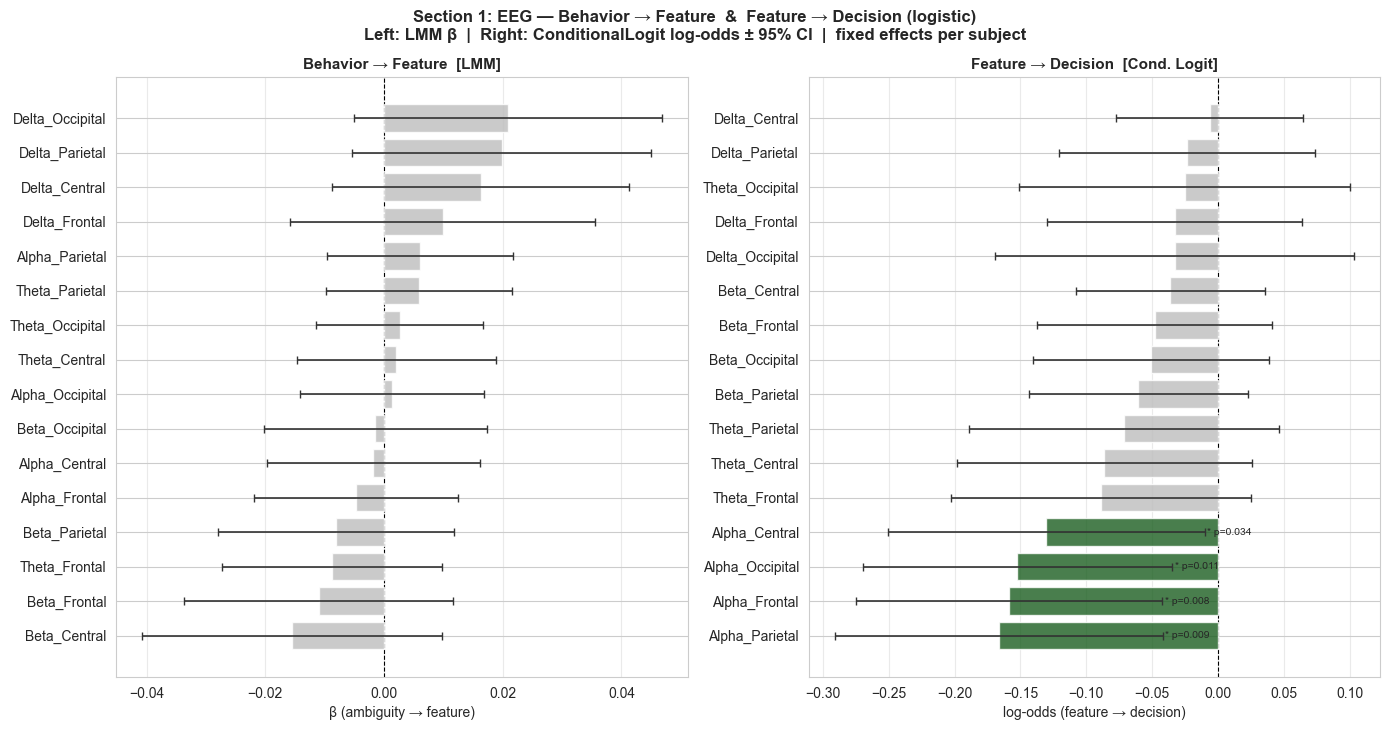

In [6]:
print('EEG → Decision — ConditionalLogit log-odds (sorted by p):')
print(eeg_scan.sort_values('p_dec')[['feature','beta_dec','se_dec','p_dec','sig_dec']].to_string(index=False))
print(f'\n  Sig EEG → decision: {eeg_scan["sig_dec"].sum()} / {len(eeg_scan)}')
print(f'  Sig both directions: {(eeg_scan["sig_beh"] & eeg_scan["sig_dec"]).sum()} / {len(eeg_scan)}')

plot_scan(eeg_scan,
          title='Section 1: EEG — Behavior → Feature  &  Feature → Decision (logistic)',
          color_beh='#4CAF50', color_dec='#1B5E20',
          save_path='../../data/results/main/statistical_analyses/logistic/lmm_eeg_scan_logistic.png')

## 1c — Mediation (EEG, logistic)

Top ambiguity-driven EEG feature: eeg_Delta_Occipital
  ambiguity β=0.0209, p=1.145e-01

MEDIATION (logistic): Ambiguity → Delta_Occipital → Decision
  Path a (ambig → med) [LMM]:          β=0.0209, p=1.145e-01 ns
  Path b (med → outcome) [CondLogit]:  log-OR=-0.0329, p=6.355e-01 ns
  Total effect (c) [CondLogit]:         log-OR=-0.8229, p=3.108e-128
  Direct effect (c') [CondLogit]:       log-OR=-0.8224, p=4.939e-128
  Indirect (a×b):         -0.00069
  Sobel z=-0.454,  p=6.499e-01
  Proportion mediated:    0.1%
  → No significant mediation


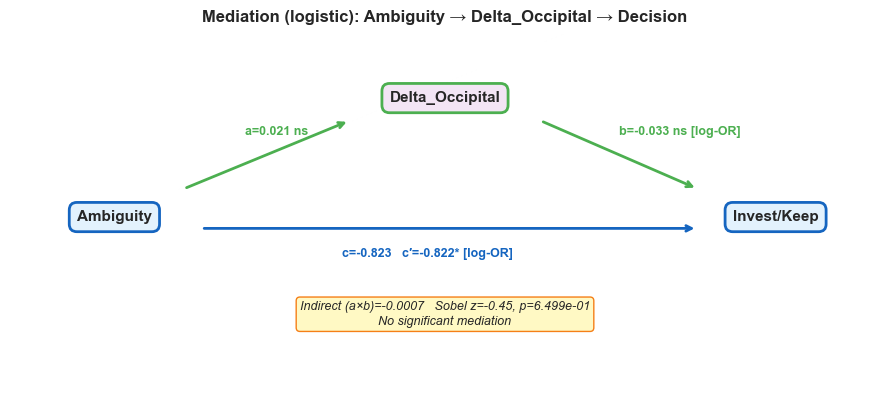

In [7]:
top_eeg = eeg_scan.sort_values('p_beh').iloc[0]
print(f'Top ambiguity-driven EEG feature: {top_eeg["feature"]}')
print(f'  ambiguity β={top_eeg["beta_beh"]:.4f}, p={top_eeg["p_beh"]:.3e}')
print()

eeg_med = run_mediation(top_eeg['feature'], top_eeg['feature'].replace('eeg_',''),
                        df_eeg, TASK_FORMULA_COLS, TASK_CTRL_COLS)
plot_mediation(eeg_med, color='#4CAF50',
               save_path='../../data/results/main/statistical_analyses/logistic/lmm_eeg_mediation_logistic.png')

---
# Section 2 — Pupil

**Features**: 13 pre-decision pupil features  
**Coverage**: 102 subjects, ~12,100 trials

In [8]:
pupil_cols = [c for c in physio_cols if c.endswith('_pre')]

df_pupil = merged_df[behavior_keep + pupil_cols].dropna(subset=pupil_cols).copy().reset_index(drop=True)
df_pupil = zscore_cols(df_pupil, ['ambiguity', 'ev_difference', 'decision_time',
                                   'running_invest_rate'] + pupil_cols)

print(f'Pupil dataset: {len(df_pupil)} trials, {df_pupil["subject_id"].nunique()} subjects')
var_subj = df_pupil.groupby('subject_id')['outcome'].std()
print(f'Subjects with outcome variance: {(var_subj > 0).sum()} / {len(var_subj)}')

Pupil dataset: 12107 trials, 102 subjects
Subjects with outcome variance: 98 / 102


## 2a — Behavior → Pupil

In [9]:
pupil_scan = scan_features(pupil_cols, df_pupil, TASK_FORMULA_COLS, TASK_CTRL_COLS)

print(f'Behavior → Pupil scan: {len(pupil_scan)} features')
print(f'  Sig ambiguity → pupil: {pupil_scan["sig_beh"].sum()} / {len(pupil_scan)}')
print()
print('Ambiguity effects (sorted by p):')
print(pupil_scan.sort_values('p_beh')[['feature','beta_beh','se_beh','p_beh','sig_beh']].to_string(index=False))

/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Behavior → Pupil scan: 13 features
  Sig ambiguity → pupil: 0 / 13

Ambiguity effects (sorted by p):
                        feature  beta_beh   se_beh    p_beh  sig_beh
                 pupil_mean_pre -0.013195 0.007839 0.092345    False
     pupil_acceleration_std_pre  0.010793 0.006914 0.118482    False
    pupil_max_dilation_rate_pre  0.008268 0.008315 0.320026    False
          pct_time_dilating_pre  0.007899 0.008443 0.349507    False
        pupil_velocity_mean_pre  0.005913 0.006381 0.354059    False
              eye_asymmetry_pre -0.005974 0.007063 0.397684    False
         num_dilation_peaks_pre -0.005955 0.007969 0.454927    False
pupil_max_constriction_rate_pre  0.005173 0.007297 0.478434    False
                  pupil_std_pre -0.004129 0.006737 0.539943    False
                pupil_slope_pre  0.004086 0.007061 0.562808    False
          eye_asymmetry_std_pre -0.003405 0.007894 0.666273    False
                   pupil_cv_pre -0.002586 0.009132 0.777067    False
  

## 2b — Pupil → Decision  (ConditionalLogit)

Pupil → Decision — ConditionalLogit log-odds (sorted by p):
                        feature  beta_dec   se_dec        p_dec  sig_dec
                pupil_slope_pre -0.235645 0.029864 3.009257e-15     True
          pct_time_dilating_pre -0.171445 0.023882 7.031942e-13     True
                  pupil_std_pre  0.202739 0.031245 8.663759e-11     True
        pupil_velocity_mean_pre  0.125067 0.033787 2.142474e-04     True
pupil_max_constriction_rate_pre  0.079321 0.027733 4.234988e-03     True
               time_to_peak_pre -0.061726 0.023272 7.993272e-03     True
     pupil_acceleration_std_pre  0.058624 0.029164 4.441413e-02     True
              eye_asymmetry_pre  0.064612 0.032390 4.606435e-02     True
          eye_asymmetry_std_pre  0.057808 0.036429 1.125430e-01    False
                 pupil_mean_pre  0.036293 0.025609 1.564277e-01    False
         num_dilation_peaks_pre -0.034045 0.025252 1.775848e-01    False
    pupil_max_dilation_rate_pre -0.014038 0.023735 5.542132e-01 

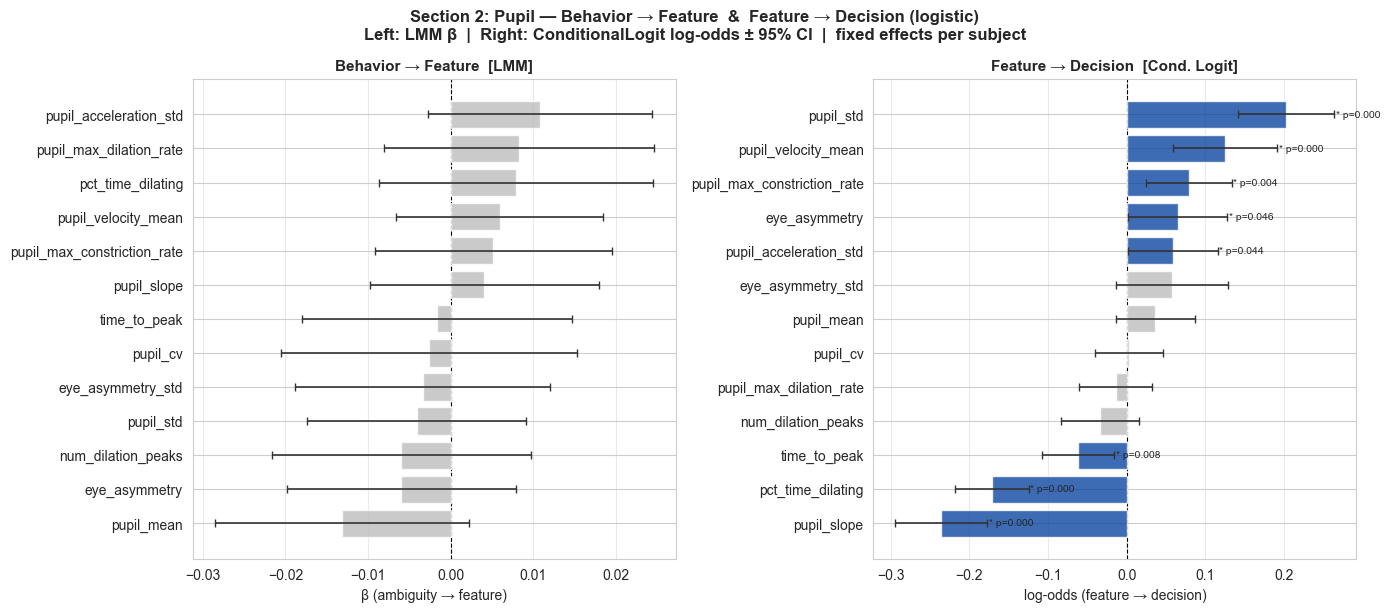

In [10]:
print('Pupil → Decision — ConditionalLogit log-odds (sorted by p):')
print(pupil_scan.sort_values('p_dec')[['feature','beta_dec','se_dec','p_dec','sig_dec']].to_string(index=False))
print(f'\n  Sig pupil → decision: {pupil_scan["sig_dec"].sum()} / {len(pupil_scan)}')
print(f'  Sig both directions:  {(pupil_scan["sig_beh"] & pupil_scan["sig_dec"]).sum()} / {len(pupil_scan)}')

plot_scan(pupil_scan,
          title='Section 2: Pupil — Behavior → Feature  &  Feature → Decision (logistic)',
          color_beh='#2196F3', color_dec='#0D47A1',
          save_path='../../data/results/main/statistical_analyses/logistic/lmm_pupil_scan_logistic.png')

## 2c — Mediation (Pupil, logistic)

Top ambiguity-driven pupil feature: pupil_mean_pre
  ambiguity β=-0.0132, p=9.234e-02

MEDIATION (logistic): Ambiguity → pupil_mean → Decision
  Path a (ambig → med) [LMM]:          β=-0.0132, p=9.234e-02 ns
  Path b (med → outcome) [CondLogit]:  log-OR=0.0363, p=1.564e-01 ns
  Total effect (c) [CondLogit]:         log-OR=-0.7791, p=1.896e-243
  Direct effect (c') [CondLogit]:       log-OR=-0.7788, p=3.858e-243
  Indirect (a×b):         -0.00048
  Sobel z=-1.084,  p=2.783e-01
  Proportion mediated:    0.1%
  → No significant mediation


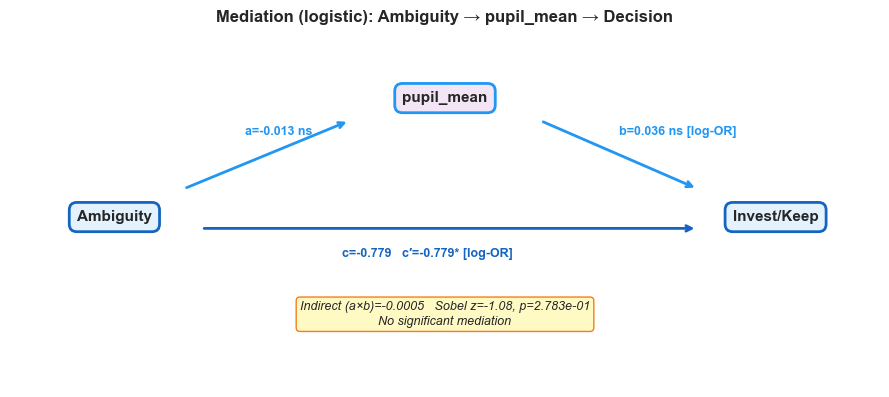

In [11]:
top_pupil = pupil_scan.sort_values('p_beh').iloc[0]
print(f'Top ambiguity-driven pupil feature: {top_pupil["feature"]}')
print(f'  ambiguity β={top_pupil["beta_beh"]:.4f}, p={top_pupil["p_beh"]:.3e}')
print()

pupil_med = run_mediation(top_pupil['feature'],
                          top_pupil['feature'].replace('_pre',''),
                          df_pupil, TASK_FORMULA_COLS, TASK_CTRL_COLS)
plot_mediation(pupil_med, color='#2196F3',
               save_path='../../data/results/main/statistical_analyses/logistic/lmm_pupil_mediation_logistic.png')

---
# Section 3 — Gaze

**Features**: 16 pre-decision gaze features  
**Coverage**: 102 subjects, ~12,100 trials

In [12]:
gaze_model_cols = [c for c in gaze_cols if c not in
                   ['gaze_valid_pct', 'fixation_ratio', 'saccade_ratio', 'saccade_count']]

df_gaze = merged_df[behavior_keep + gaze_model_cols].dropna(subset=gaze_model_cols).copy().reset_index(drop=True)
df_gaze = zscore_cols(df_gaze, ['ambiguity', 'ev_difference', 'decision_time',
                                  'running_invest_rate'] + gaze_model_cols)

print(f'Gaze dataset: {len(df_gaze)} trials, {df_gaze["subject_id"].nunique()} subjects')
var_subj = df_gaze.groupby('subject_id')['outcome'].std()
print(f'Subjects with outcome variance: {(var_subj > 0).sum()} / {len(var_subj)}')

Gaze dataset: 12107 trials, 102 subjects
Subjects with outcome variance: 98 / 102


## 3a — Behavior → Gaze

In [13]:
gaze_scan = scan_features(gaze_model_cols, df_gaze, TASK_FORMULA_COLS, TASK_CTRL_COLS)

print(f'Behavior → Gaze scan: {len(gaze_scan)} features')
print(f'  Sig ambiguity → gaze: {gaze_scan["sig_beh"].sum()} / {len(gaze_scan)}')
print()
print('Ambiguity effects (sorted by p):')
print(gaze_scan.sort_values('p_beh')[['feature','beta_beh','se_beh','p_beh','sig_beh']].to_string(index=False))

/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


Behavior → Gaze scan: 16 features
  Sig ambiguity → gaze: 11 / 16

Ambiguity effects (sorted by p):
               feature  beta_beh   se_beh        p_beh  sig_beh
            gaze_y_std -0.154543 0.007586 2.972414e-92     True
           gaze_y_mean  0.068537 0.004260 3.086960e-58     True
            gaze_x_std  0.107002 0.006842 3.931210e-55     True
         screen_y_mean -0.018243 0.003266 2.331375e-08     True
          screen_x_std  0.044347 0.008058 3.728465e-08     True
     gaze_dispersion_x  0.031577 0.008038 8.547949e-05     True
     gaze_velocity_max  0.022189 0.008085 6.062403e-03     True
           gaze_x_mean -0.021121 0.008638 1.447779e-02     True
     gaze_velocity_std  0.017100 0.007767 2.768989e-02     True
         screen_x_mean  0.013698 0.006309 2.992490e-02     True
 gaze_acceleration_std  0.016019 0.007786 3.965361e-02     True
          screen_y_std -0.012595 0.007950 1.131539e-01    False
     gaze_dispersion_y  0.009661 0.008108 2.333930e-01    False
    

## 3b — Gaze → Decision  (ConditionalLogit)

Gaze → Decision — ConditionalLogit log-odds (sorted by p):
               feature  beta_dec   se_dec         p_dec  sig_dec
            gaze_x_std -0.733233 0.033183 3.394165e-108     True
          screen_x_std -0.129053 0.024719  1.781059e-07     True
            gaze_y_std  0.050525 0.026588  5.739699e-02    False
          screen_y_std  0.028526 0.025343  2.603284e-01    False
     gaze_dispersion_y  0.023377 0.023834  3.266876e-01    False
gaze_acceleration_mean  0.024635 0.027944  3.780035e-01    False
      gaze_path_length  0.018395 0.024326  4.495365e-01    False
    gaze_velocity_mean  0.020902 0.028814  4.681994e-01    False
     gaze_dispersion_x -0.017288 0.024001  4.713350e-01    False
           gaze_y_mean -0.026536 0.046635  5.693423e-01    False
     gaze_velocity_std  0.013112 0.025883  6.124457e-01    False
 gaze_acceleration_std  0.010378 0.025973  6.894803e-01    False
         screen_x_mean -0.008902 0.033480  7.903345e-01    False
           gaze_x_mean -0.00412

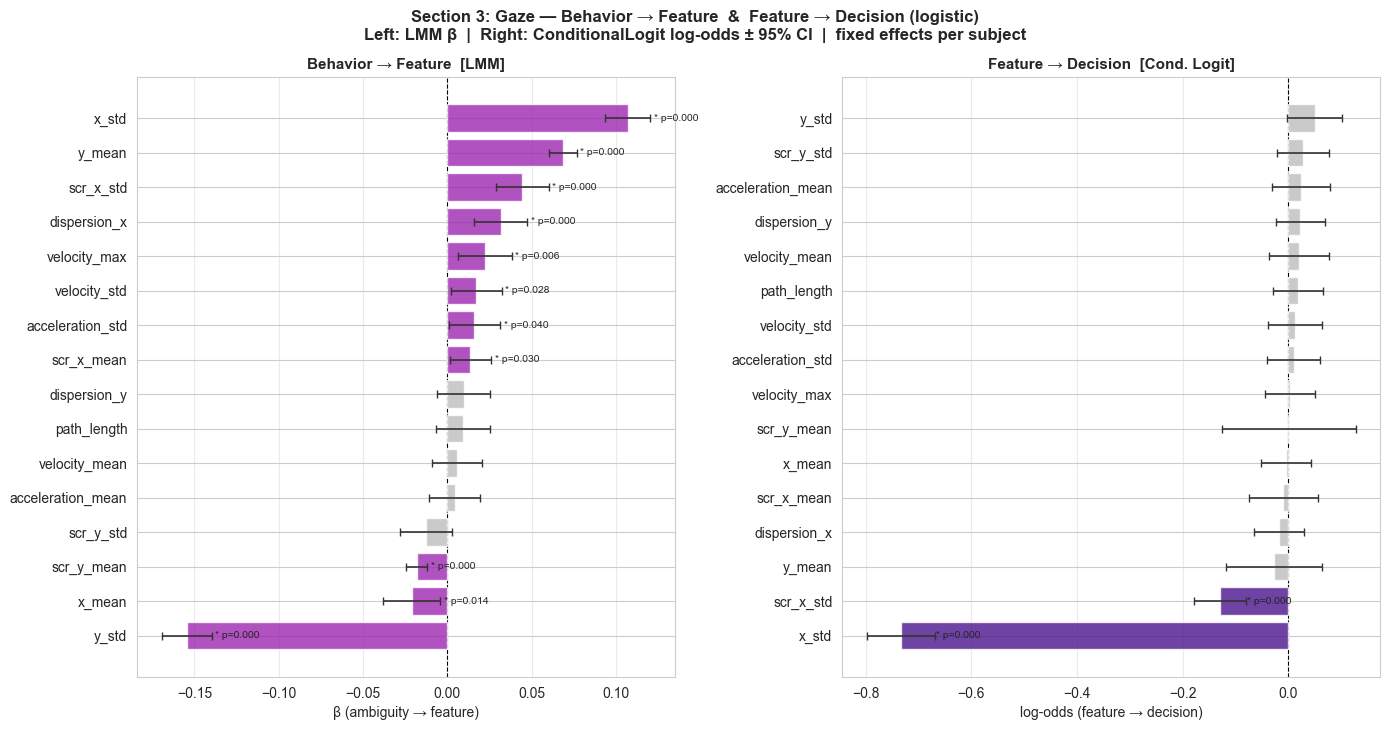

In [14]:
print('Gaze → Decision — ConditionalLogit log-odds (sorted by p):')
print(gaze_scan.sort_values('p_dec')[['feature','beta_dec','se_dec','p_dec','sig_dec']].to_string(index=False))
print(f'\n  Sig gaze → decision:  {gaze_scan["sig_dec"].sum()} / {len(gaze_scan)}')
print(f'  Sig both directions:  {(gaze_scan["sig_beh"] & gaze_scan["sig_dec"]).sum()} / {len(gaze_scan)}')

plot_scan(gaze_scan,
          
          title='Section 3: Gaze — Behavior → Feature  &  Feature → Decision (logistic)',
          color_beh='#9C27B0', color_dec='#4A148C',
          save_path='../../data/results/main/statistical_analyses/logistic/lmm_gaze_scan_logistic.png')

## 3c — Mediation (Gaze, logistic)

Top ambiguity-driven gaze feature: gaze_y_std
  ambiguity β=-0.1545, p=2.972e-92

MEDIATION (logistic): Ambiguity → y_std → Decision
  Path a (ambig → med) [LMM]:          β=-0.1545, p=2.972e-92 *
  Path b (med → outcome) [CondLogit]:  log-OR=0.0505, p=5.740e-02 ns
  Total effect (c) [CondLogit]:         log-OR=-0.7791, p=1.896e-243
  Direct effect (c') [CondLogit]:       log-OR=-0.7720, p=5.040e-233
  Indirect (a×b):         -0.00781
  Sobel z=-1.892,  p=5.848e-02
  Proportion mediated:    1.0%
  → No significant mediation


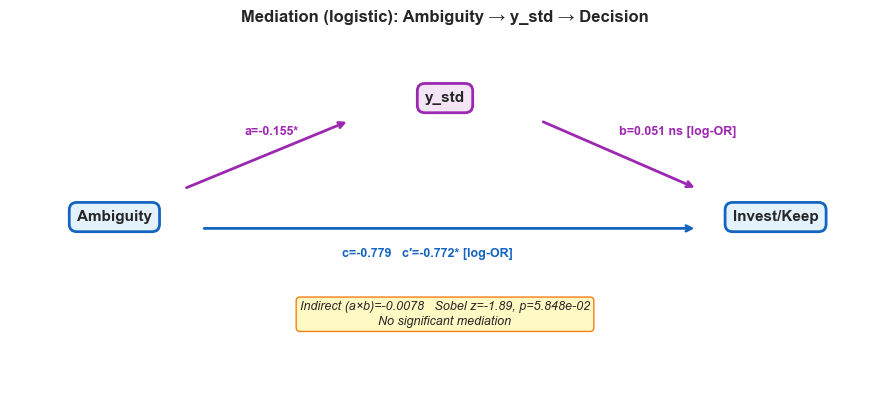

In [15]:
top_gaze = gaze_scan.sort_values('p_beh').iloc[0]
print(f'Top ambiguity-driven gaze feature: {top_gaze["feature"]}')
print(f'  ambiguity β={top_gaze["beta_beh"]:.4f}, p={top_gaze["p_beh"]:.3e}')
print()

gaze_med = run_mediation(top_gaze['feature'],
                         top_gaze['feature'].replace('gaze_','').replace('screen_','scr_'),
                         df_gaze, TASK_FORMULA_COLS, TASK_CTRL_COLS)
plot_mediation(gaze_med, color='#9C27B0',
               save_path='../../data/results/main/statistical_analyses/logistic/lmm_gaze_mediation_logistic.png')

---
# Summary — Logistic vs Linear Comparison

Compare significant feature counts between the LMM (linear probability model, notebook 11) and this logistic notebook to assess whether conclusions change with the correct link function.

In [16]:
print('='*70)
print('GLMM BRAIN-BEHAVIOR SUMMARY  (ConditionalLogit for binary outcome)')
print('='*70)
print(f'Direction A (behavior → feature):  LMM, Gaussian')
print(f'Direction B (feature → decision):  ConditionalLogit, logit link')
print()

for label, scan, med in [
    ('EEG   (16 features, 80 subj)',  eeg_scan,   eeg_med),
    ('Pupil (13 features, 102 subj)', pupil_scan, pupil_med),
    ('Gaze  (16 features, 102 subj)', gaze_scan,  gaze_med),
]:
    print(f'{label}')
    print(f'  Behavior → feature:  {scan["sig_beh"].sum()} sig.')
    print(f'  Feature → decision:  {scan["sig_dec"].sum()} sig.  [log-odds]')
    print(f'  Both directions:     {(scan["sig_beh"] & scan["sig_dec"]).sum()} sig.')
    print(f'  Mediation ({med["label"]}):')
    print(f'    Indirect a×b={med["indirect"]:.4f},  Sobel p={med["sobel_p"]:.3e}  → {med["verdict"]}')
    print()

GLMM BRAIN-BEHAVIOR SUMMARY  (ConditionalLogit for binary outcome)
Direction A (behavior → feature):  LMM, Gaussian
Direction B (feature → decision):  ConditionalLogit, logit link

EEG   (16 features, 80 subj)
  Behavior → feature:  0 sig.
  Feature → decision:  4 sig.  [log-odds]
  Both directions:     0 sig.
  Mediation (Delta_Occipital):
    Indirect a×b=-0.0007,  Sobel p=6.499e-01  → No significant mediation

Pupil (13 features, 102 subj)
  Behavior → feature:  0 sig.
  Feature → decision:  8 sig.  [log-odds]
  Both directions:     0 sig.
  Mediation (pupil_mean):
    Indirect a×b=-0.0005,  Sobel p=2.783e-01  → No significant mediation

Gaze  (16 features, 102 subj)
  Behavior → feature:  11 sig.
  Feature → decision:  2 sig.  [log-odds]
  Both directions:     2 sig.
  Mediation (y_std):
    Indirect a×b=-0.0078,  Sobel p=5.848e-02  → No significant mediation

